# Test de fonctions bas-niveau pour le déaliasing

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent      # pyTQG
SRC = ROOT / "pyTQG_solver"

print(ROOT)
print(SRC)
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG
C:\Users\evanl\Documents\Cours M2 POC\Stage LOPS\pyTQG\pyTQG_solver


In [2]:
import numpy as np
import numpy.matlib
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
import time
import hvplot.xarray
import xarray as xr
import IPython.display as ipd
import collections

import matplotlib.colors as colors

import ipywidgets as widgets
%matplotlib widget


#Modules maison
import fourier as Fourier
import chebyshev as Chebyshev
import parameters as Params
import time_scheme as TimeScheme

## Fourier : règle des 2/3

kx = [  0.   1.   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.
  14.  15.  16.  17.  18.  19.  20.  21.  22.  23.  24.  25.  26.  27.
  28.  29.  30.  31.  32.  33.  34.  35.  36.  37.  38.  39.  40.  41.
  42.  43.  44.  45.  46.  47.  48.  49.  50.  51.  52.  53.  54.  55.
  56.  57.  58.  59.  60.  61.  62.  63. -64. -63. -62. -61. -60. -59.
 -58. -57. -56. -55. -54. -53. -52. -51. -50. -49. -48. -47. -46. -45.
 -44. -43. -42. -41. -40. -39. -38. -37. -36. -35. -34. -33. -32. -31.
 -30. -29. -28. -27. -26. -25. -24. -23. -22. -21. -20. -19. -18. -17.
 -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.
  -2.  -1.]


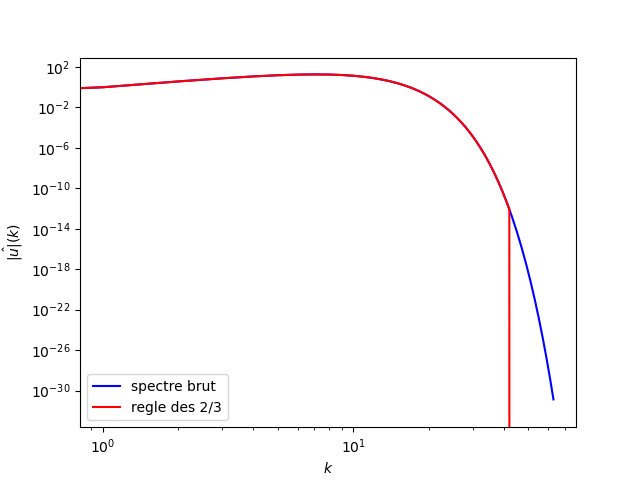

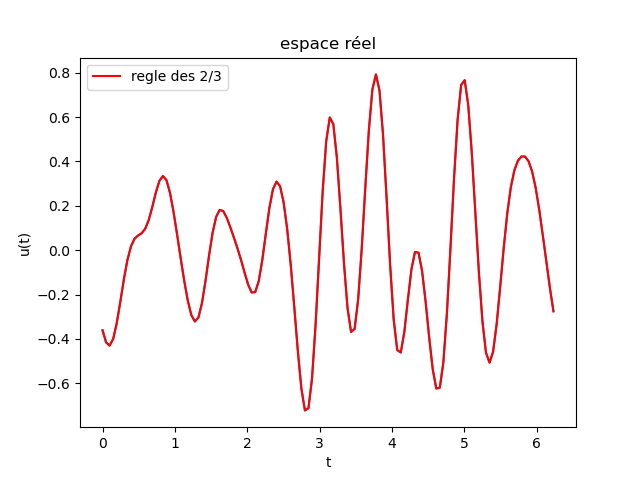

In [3]:
#spectre de Passot-Pouquet
PSD_PP = lambda kk, A=1.0, kp=5.0 : A*(kk**4)*np.exp(-(kk/kp)**2)
#PSD_PP = lambda kk,km =10.0, sigma = 3.0: np.exp(-(kk-km)**2/(2.0*sigma**2))


N=128
x = np.linspace(0.0, 2.0*np.pi, N, endpoint = False)
kx = 2.0*np.pi*scipy.fft.fftfreq(N, d=x[1]-x[0]) 

u_hat_abs = np.sqrt(PSD_PP(kx))
u_hat = u_hat_abs*np.exp(1.j*np.random.uniform(0.0, x[-1], size=N))


print(f"kx = {kx}")

coeff_dealias = 2.0/3.0
u_hat_dealias = np.where(np.abs(kx) < coeff_dealias*np.abs(kx).max(), u_hat.copy(), 0.0)

u_dealias = scipy.fft.ifft(u_hat_dealias).real

u = scipy.fft.ifft(u_hat).real

fig = plt.figure()
plt.plot(scipy.fft.fftshift(kx), scipy.fft.fftshift(u_hat_abs), label = 'spectre brut', color = 'b')
plt.plot(scipy.fft.fftshift(kx), scipy.fft.fftshift(np.abs(u_hat_dealias)), label = "regle des 2/3", color = 'r')
plt.xlabel(r'$k$')
plt.ylabel(r"$\hat{|u|}(k)$")
plt.xscale('log')
plt.yscale('log')
plt.legend()

fig = plt.figure()
plt.title("espace réel")
plt.plot(x, u)
plt.plot(x, u_dealias, label = "regle des 2/3", color = 'r')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.legend()

In [4]:
kx

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63., -64., -63.,
       -62., -61., -60., -59., -58., -57., -56., -55., -54., -53., -52.,
       -51., -50., -49., -48., -47., -46., -45., -44., -43., -42., -41.,
       -40., -39., -38., -37., -36., -35., -34., -33., -32., -31., -30.,
       -29., -28., -27., -26., -25., -24., -23., -22., -21., -20., -19.,
       -18., -17., -16., -15., -14., -13., -12., -11., -10.,  -9.,  -8.,
        -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.])

## Chebyshev : filtre exponentiel

Pour rappel, dans la base de Chebyshev, une fonction $f$ est représentée par 
$$
\begin{aligned}
f(x) &= \sum_{k=0}^N c_k T_k(x)\\
x&\in[-1, 1]
\end{aligned}
$$
Le filtrage exponentiel consiste à atténuer les modes de $k$ élevé, en agissant directement sur les coefficients : 
$$
\begin{aligned}
c^{fil}_k &= \sigma(k) c_k\\
\sigma(k) &= \exp{-\alpha(\frac{|k|}{N})^p}
\end{aligned}
$$

Il y a 2 manières de le faire : 
- Soit on calcule les coefficients par un fit polynomial, on applique le filtre, puis on réévalue la fonction. Cela se fait avec le module `numpy.polynomial.chebyshev`. C'est très simple à mettre en oeuvre, mais c'est très couteux en temps. 

- On peut aussi écrire (je renvoie au chapitre 7 de Trefethen):
  $$
  \begin{aligned}
  f(\theta) &= \sum_{k=0}^N a_k\cos{k\theta}\\
  \theta &\in [0, 2\pi]
  \end{aligned}
  $$

  Dans ce cas, le calcul des coefficients se fait avec la Transformée en Cosinus Discrète. On applique ensuite le filtre, puis on utilise la transformée inverse. C'est bien plus rapide, et tout aussi simple.

Text(0, 0.5, 'y')

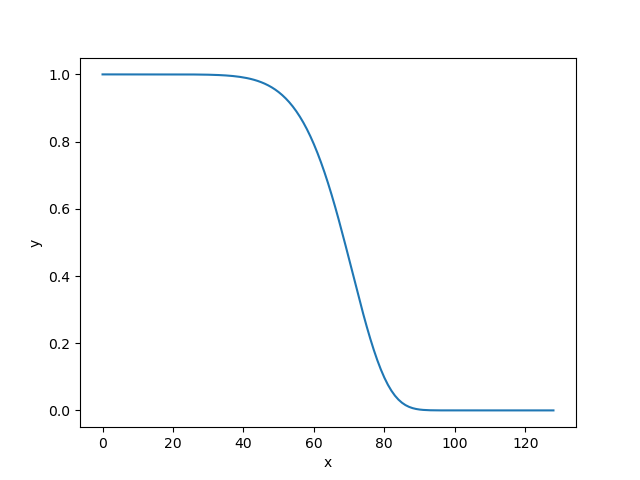

In [5]:
k = np.arange(0.0, 129.0)
fig = plt.figure()

alpha = 100
p = 8.0
f_exp = np.exp(-alpha*(np.abs(k)/k.max())**p)

plt.plot(k, f_exp)
plt.xlabel('x')
plt.ylabel('y')


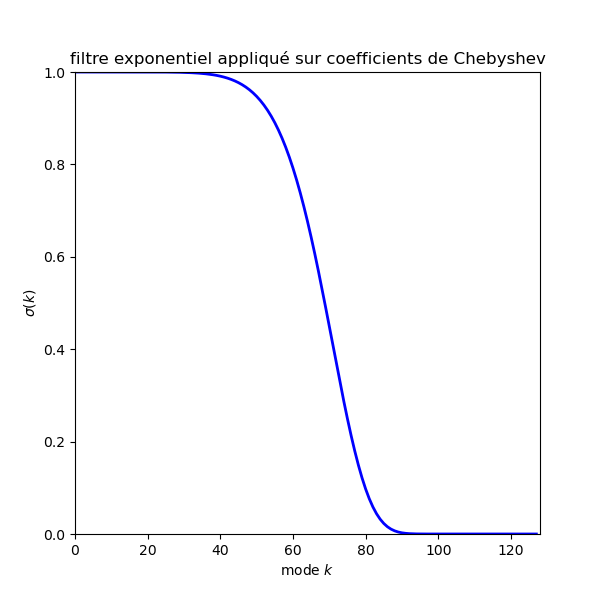

In [6]:
N = 128
k = np.arange(0.0, float(N))


fig = plt.figure(figsize = (6, 6))
fig.canvas.header_visible = False

ax = plt.axes()
line_amplitude, = ax.plot([], [], color='b', lw=2)
ax.set_title("filtre exponentiel appliqué sur coefficients de Chebyshev")
ax.set_xlabel("mode $k$")
ax.set_ylabel(r"$\sigma(k)$")
ax.set_xlim(0.0, N)
ax.set_ylim(0.0, 1.0)


def update_exp_filter(Alpha, P):
    sigma = np.exp(-Alpha*(k/N)**P)
    line_amplitude.set_data(k, sigma)
    fig.canvas.draw_idle()
    

slider_alpha = widgets.FloatSlider(value=100.0, min=10.0, max=500.0, step=20.0, description='alpha :')
slider_p = widgets.FloatSlider(value=8.0, min=0.0, max=15.0, step=1.0, description='p :')

# Liaison des sliders à la fonction
interactive_output = widgets.interactive_output(update_exp_filter, {'Alpha': slider_alpha, 'P': slider_p})

# Éléments d'interface utilisateur alignés verticalement
widgets.VBox([widgets.HBox([slider_alpha, slider_p]), interactive_output])

In [7]:
import numpy.polynomial as nppol

def Cheb_exp_filter(u, x, alpha=100.0, p=8.0, interior = True):
    u_res = np.copy(u)
    N = u.size
    k = np.arange(0, N, dtype = u.dtype)
    coeffs = nppol.chebyshev.chebfit(x, u_res, N-1)
    filtre = np.exp(-alpha*( (k/N)**p) )
    coeffs_filtered = filtre*coeffs
    u_res = nppol.chebyshev.chebval(x, coeffs_filtered)
    return u_res

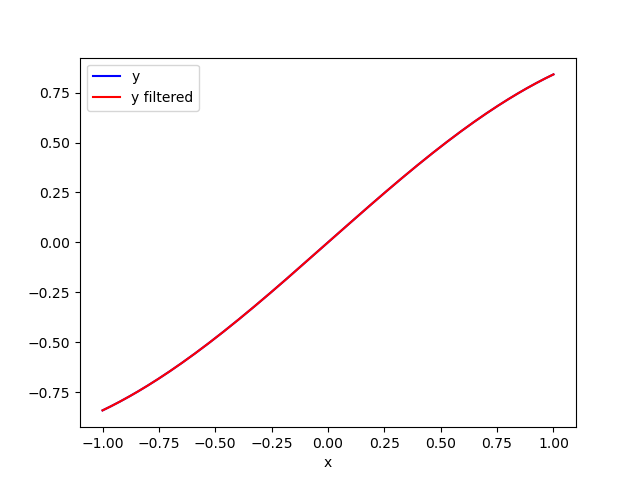

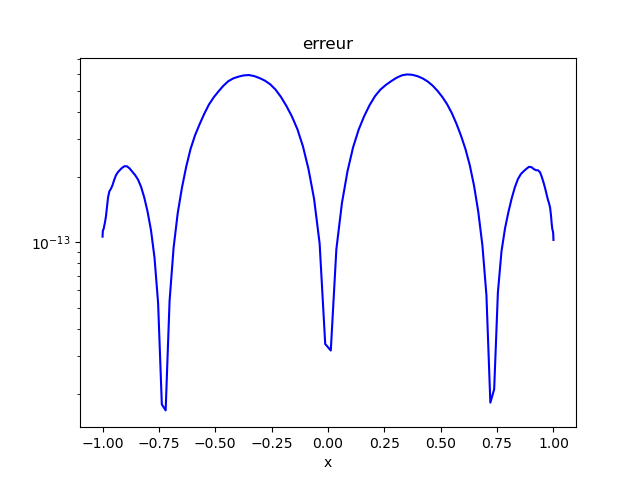

In [8]:
N_C=128
x_C = Chebyshev.collocation_points(N_C)

y_C = np.sin(x_C)

y_filter = Cheb_exp_filter(y_C, x_C)

err = np.abs(y_C - y_filter)

fig = plt.figure()
plt.plot(x_C, y_C, color = 'b', label ='y')
plt.plot(x_C, y_filter, color = 'r', label = 'y filtered')
plt.xlabel('x')
plt.legend()

fig = plt.figure()
plt.title('erreur')
plt.plot(x_C, err, color = 'b')
plt.xlabel('x')
plt.yscale('log')

In [9]:
%timeit Cheb_exp_filter(y_C, x_C)

2.21 ms ± 150 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [10]:
#On vérifie si ça garde les CLs
y_test = np.sin(x_C)
y_ini = y_test.copy()

print(f"y[0] = {y_test[0]}")
print(f"y[-1] = {y_test[-1]}")
N_tests = 10000



for i in range(0, N_tests):
    y_test = Cheb_exp_filter(y_test, x_C)

print(f"après N_test = {N_tests} filtrages")
print(f"y[0] = {y_test[0]}, erreur = {np.abs(y_ini[0]-y_test[0]):.4e}")
print(f"y[-1] = {y_test[-1]}, erreur = {np.abs(y_ini[-1]-y_test[-1]):.4e}")

y[0] = 0.8414709848078965
y[-1] = -0.8414709848078965
après N_test = 10000 filtrages
y[0] = 0.8414709858596091, erreur = 1.0517e-09
y[-1] = -0.8414709858977566, erreur = 1.0899e-09


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Text(0.5, 0, 'x')

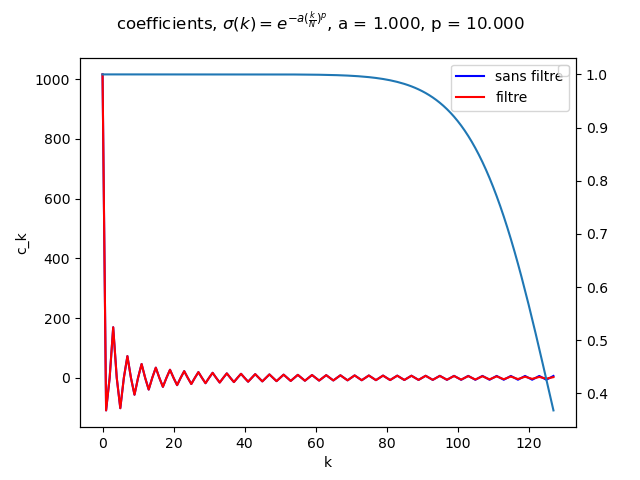

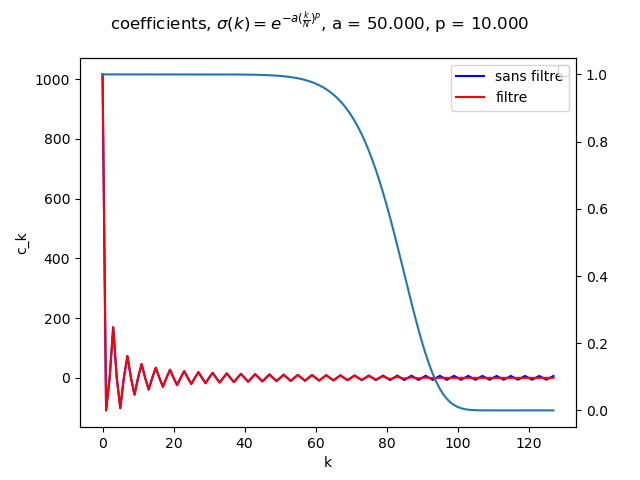

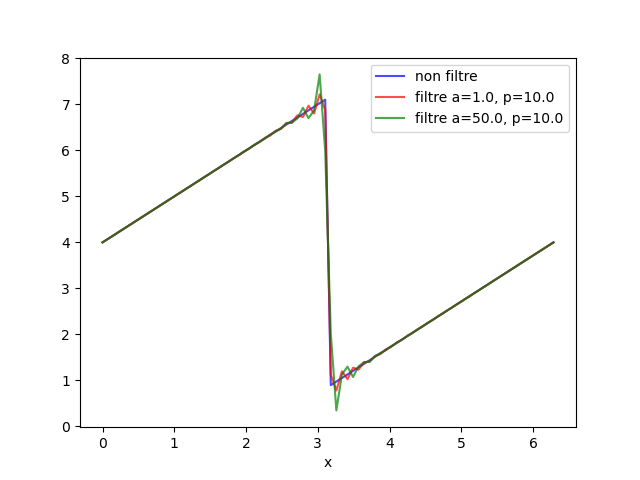

In [11]:
def exp_filter_DCT_test(v, x, alpha=1.0, p=8.0, interior = False):
    if type(v) !=np.ndarray:
        v = np.array(v)
    N = v.size
    k = np.arange(0, N)
    V_DCT = scipy.fft.dct(v, type=1)
    #print(f"k = {k}")
    #print(f"V_DCT = {V_DCT}")
    #print(f"V_DCT.size = {V_DCT.size}")
    #K_DCT = np.concatenate((ii, [0], -np.flip(k)[1:-1]))
    filtre_exp = np.exp(-alpha*(k/k.max())**p)
    V_DCT_filter = filtre_exp*V_DCT
    #V_DCT_filter = V_DCT
    #print(f"V_DCT_filter = {V_DCT_filter}")
    #print(f"V_DCT_filter-V_DCT = {np.abs(V_DCT_filter-V_DCT)}")
    V_FILTER = scipy.fft.idct(V_DCT_filter, type=1)

    fig = plt.figure()
    fig.suptitle(r"coefficients, $\sigma(k) = e^{-a(\frac{k}{N})^p}$, "+f"a = {alpha:.3f}, p = {p:.3f}")
    ax = plt.axes()
    ax_fil = ax.twinx()
    ax.plot(k, V_DCT, label = 'sans filtre', color= 'b')
    ax.plot(k, V_DCT_filter, label = 'filtre', color= 'r')
    ax.set_xlabel('k')
    ax_fil.plot(k,filtre_exp)
    ax.set_ylabel('c_k')
    ax.legend()
    ax_fil.legend()
    res=np.zeros(N+1)
    if not interior:
        res = V_FILTER[0:N+1]
    else:
        res[1:-1] = V_FILTER[1:N]
        res[0] = v[0]
        res[-1] = v[-1]
    #print(f"res = {res}")
    #print(f"res.size = {res.size}")
    #print(f"res - v = {np.abs(res - v)}")
    return res
N_1=128
x_1 = Chebyshev.collocation_points(N_1, a=0.0, b = 2.0*np.pi)
#uu = np.cos(x_1)*x_1**8+x**2*np.exp(x**4/3.0)
visc = 0.005
uu = 4.0+(x_1*np.exp(-(x_1**2)/(4.0*visc))+(x_1-2.0*np.pi)*np.exp(-((x_1-2.0*np.pi)**2)/(4.0*visc)))/(np.exp(-(x_1**2)/(4.0*visc))+np.exp(-((x_1-2.0*np.pi)**2)/(4.0*visc)))

a_1, p_1 = 1.0, 10.0
a_2, p_2 = 50.0, 10.0

uu_filter_1 = exp_filter_DCT_test(uu, x_1, alpha=a_1, p=p_1)
uu_filter_2 = exp_filter_DCT_test(uu, x_1, alpha=a_2, p=p_2)

fig = plt.figure()
plt.plot(x_1, uu, label ='non filtre', color='b', alpha=0.7)
plt.plot(x_1, uu_filter_1, label =f'filtre a={a_1}, p={p_1}', color = 'r', alpha = 0.7)
plt.plot(x_1, uu_filter_2, label =f'filtre a={a_2}, p={p_2}', color = 'g', alpha = 0.7)
plt.legend()
plt.xlabel('x')

In [12]:
def exp_filter_DCT(v, alpha=100.0, p=8.0, interior = True, axis = None):
    if type(v) !=np.ndarray:
        v = np.array(v)

        
    if axis is None:
        axis = -1
        N = v.size
    elif axis == "x":
        axis = 0
        N = v.shape[0]
    elif axis == "y":
        axis = 1
        N = v.shape[1]
    else:
        raise ValueError(f"axis must be in ('x', 'y', None), current value = {axis}")
    
    v_res = v.copy()
    if interior:
        N-=2
        v_fil = sel_interior_points(v, axis)
    else : 
        v_fil = v.copy()
    k=np.arange(0, N)
    if axis == 0:#On transforme k en vecteur colonne
            k = k[..., None]
    #print(f"interior = {interior}")
    #print(f"v_fil.shape = {v_fil.shape}")
    #print(f"v.shape = {v.shape}")
    V_DCT = scipy.fft.dct(v_fil, type = 1, axis = axis)
    filtre_exp = np.exp(-alpha*(k/k.max())**p)
    V_DCT_filter = filtre_exp*V_DCT

    V_FILTER = scipy.fft.idct(V_DCT_filter, type=1, axis = axis)
    if not interior:
        return v_fil
    else:
        insert_interior_points(v_res, V_FILTER, axis)
    return v_res

def sel_interior_points(val, axis):
    sel = [slice(None)]*val.ndim
    sel[axis] = slice(1, -1)
    return val[tuple(sel)]

def insert_interior_points(array, vals_to_insert, axis):
    sel = [slice(None)]*array.ndim
    sel[axis] = slice(1, -1)
    array[tuple(sel)] = vals_to_insert
    return array
    
N_fil = 100000

uu_filter_int = exp_filter_DCT(uu)
uu_filter_ext = exp_filter_DCT(uu, interior = False)


for i in range(0, N_fil):
    uu_filter_int = exp_filter_DCT(uu_filter_int)
    uu_filter_ext = exp_filter_DCT(uu_filter_ext, interior = False)
    
err_u_fil_int = np.abs(uu-uu_filter_int)
err_u_fil_ext = np.abs(uu-uu_filter_ext)

print(f"Après {N_fil} filtrages successifs")
print(f"Filtrage sur points intérieurs : err[0] = {err_u_fil_int[0]:.4e} , err[-1] = {err_u_fil_int[-1]:.4e}")
print(f"Filtrage sur points extérieurs : err[0] = {err_u_fil_ext[0]:.4e} , err[-1] = {err_u_fil_ext[-1]:.4e}")

Après 100000 filtrages successifs
Filtrage sur points intérieurs : err[0] = 0.0000e+00 , err[-1] = 0.0000e+00
Filtrage sur points extérieurs : err[0] = 0.0000e+00 , err[-1] = 0.0000e+00


## Applications sur fonction 2D

In [13]:
import dealiasing

In [14]:
N = 128
x = np.linspace(0.0, 2.0*np.pi, N, endpoint = False)
y = Chebyshev.collocation_points(N)
X, Y = np.meshgrid(x, y, indexing = 'ij')

f_x = np.cos(X)*np.cosh(Y)

f_dealias_x = dealiasing.Fourier_dealias(f_x, x[1]-x[0], axis = 'x')
f_dealias_y = exp_filter_DCT(f_x, axis = 'y')

def plot_err(err_array, title='', lognorm = True):
    fig  = plt.figure()
    ax=plt.axes()
    ax.set_title(title)
    cf = ax.pcolormesh(X, Y, err_array, norm=colors.LogNorm(vmin=1.0e-15, vmax=err_array.max()) if lognorm else None)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    fig.colorbar(cf, ax=ax)

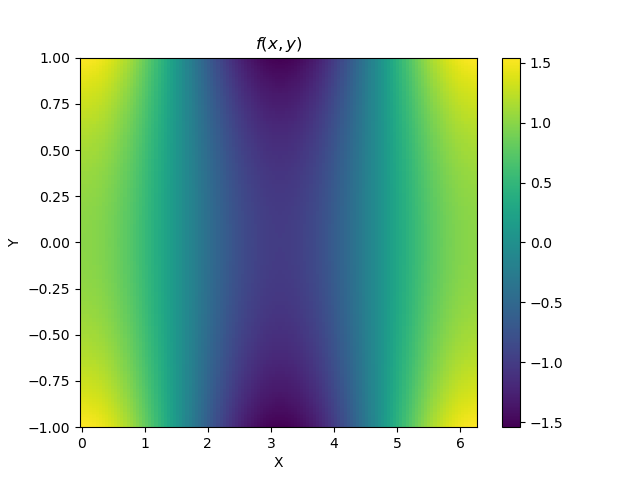

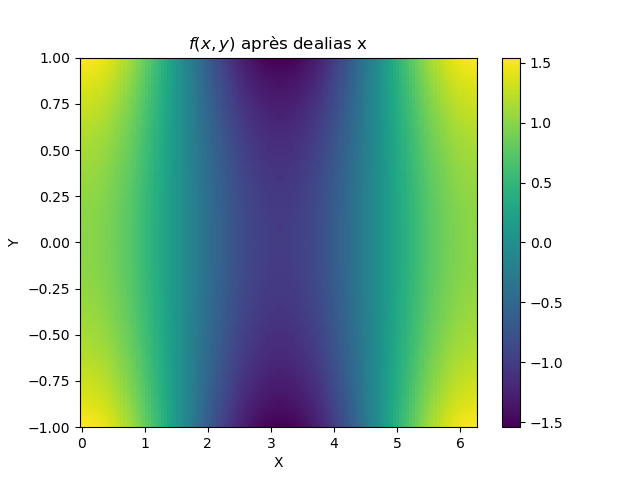

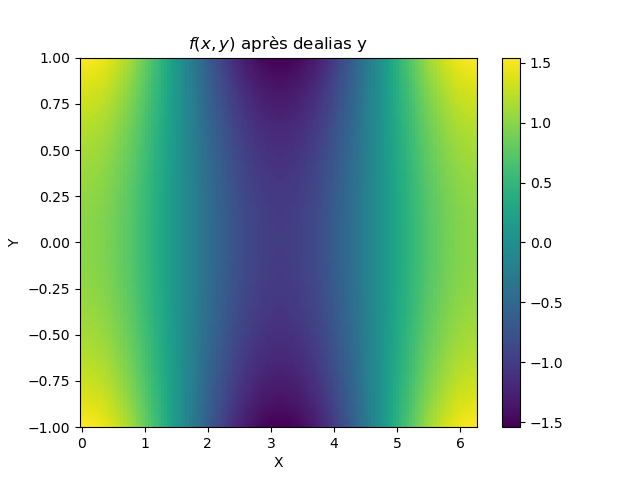

In [15]:
plot_err(f_x, lognorm = False, title = r"$f(x,y)$")
plot_err(f_dealias_x, lognorm = False, title = r"$f(x,y)$ après dealias x")
plot_err(f_dealias_y, lognorm = False, title = r"$f(x,y)$ après dealias y")

In [16]:
tps = 125.56
print(f"{tps //60} : {tps%60}")

2.0 : 5.560000000000002
